In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from urllib.parse import urlparse
from datetime import datetime
from collections import Counter

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

In [ ]:
DATASET_PATH = "FakenewsBR_factchecked.csv"

df = pd.read_csv(DATASET_PATH)

print("Dimensão do dataset (linhas, colunas):")
print(df.shape)

print("\nColunas do dataset:")
print(df.columns.tolist())

print("\nTipos de dados:")
display(df.dtypes)

print("\nAmostra das primeiras linhas:")
display(df.head())


Dimensão do dataset (linhas, colunas):
(51205, 17)

Colunas do dataset:
['rid', 'dataset_name', 'source_type', 'source_description', 'label', 'date_iso', 'url_review', 'text', 'text_clean', 'text_no_url', 'extracted_urls', 'is_duplicated', 'is_null', 'too_short', 'factcheck_rating', 'factcheck_claimant', 'factcheck_url']

Tipos de dados:


,0
rid,int64
dataset_name,object
source_type,object
source_description,object
label,object
date_iso,object
url_review,object
text,object
text_clean,object
text_no_url,object



Amostra das primeiras linhas:


,rid,dataset_name,source_type,source_description,label,date_iso,url_review,text,text_clean,text_no_url,extracted_urls,is_duplicated,is_null,too_short,factcheck_rating,factcheck_claimant,factcheck_url
0,0,COVID19.BR,news,Mensagens de WhatsApp em português brasileiro sobre COVID-19 coletadas em grupos públicos em 2020.,true,NaN,NaN,"O ministro da Ciência, Tecnologia, Inovações e Comunicações, Marcos Pontes, afirmou, nesta terça-feira (9), que foram iniciados os novos testes com o vermífugo nitazoxanida em pacientes que tenham...","o ministro da ciencia, tecnologia, inovacoes e comunicacoes, marcos pontes, afirmou, nesta terca-feira (9), que foram iniciados os novos testes com o vermifugo nitazoxanida em pacientes que tenham...","O ministro da Ciência, Tecnologia, Inovações e Comunicações, Marcos Pontes, afirmou, nesta terça-feira (9), que foram iniciados os novos testes com o vermífugo nitazoxanida em pacientes que tenham...",[],0,0,0,NaN,NaN,NaN
1,1,COVID19.BR,news,Mensagens de WhatsApp em português brasileiro sobre COVID-19 coletadas em grupos públicos em 2020.,fake,NaN,NaN,Pesquisa com mais de 6.000 médicos em 30 países diz que hidroxicloroquina é o tratamento mais eficaz para coronavírus.,pesquisa com mais de 6.000 medicos em 30 paises diz que hidroxicloroquina e o tratamento mais eficaz para coronavirus.,Pesquisa com mais de 6.000 médicos em 30 países diz que hidroxicloroquina é o tratamento mais eficaz para coronavírus.,[],0,0,0,NaN,NaN,NaN
2,2,COVID19.BR,news,Mensagens de WhatsApp em português brasileiro sobre COVID-19 coletadas em grupos públicos em 2020.,true,NaN,NaN,"É com muita alegria que comunico que mais um pedido nosso relacionado ao Coronavírus foi atendido! O Ministério da Educação decidiu adiantar a formatura dos estudantes de Medicina, Enfermagem e ou...","e com muita alegria que comunico que mais um pedido nosso relacionado ao coronavirus foi atendido! o ministerio da educacao decidiu adiantar a formatura dos estudantes de medicina, enfermagem e ou...","É com muita alegria que comunico que mais um pedido nosso relacionado ao Coronavírus foi atendido! O Ministério da Educação decidiu adiantar a formatura dos estudantes de Medicina, Enfermagem e ou...",[],0,0,0,NaN,NaN,NaN
3,3,COVID19.BR,news,Mensagens de WhatsApp em português brasileiro sobre COVID-19 coletadas em grupos públicos em 2020.,true,NaN,NaN,"Renda Brasil unificará vários programas sociais. O ministro da Economia, Paulo Guedes, anunciou que o governo federal criará um programa de renda mínima permanente, após a pandemia do novo coronav...","renda brasil unificara varios programas sociais. o ministro da economia, paulo guedes, anunciou que o governo federal criara um programa de renda minima permanente, apos a pandemia do novo coronav...","Renda Brasil unificará vários programas sociais. O ministro da Economia, Paulo Guedes, anunciou que o governo federal criará um programa de renda mínima permanente, após a pandemia do novo coronav...",[],0,0,0,NaN,NaN,NaN
4,4,COVID19.BR,news,Mensagens de WhatsApp em português brasileiro sobre COVID-19 coletadas em grupos públicos em 2020.,true,NaN,NaN,O Secretário-Geral da OTAN Jens Stoltenberg também ex Primeiro Ministro da Noruega 2000-2013 em seu pronunciamento sobre o lançamento do programa #NATO2030 - Fortalecendo a Aliança em um mundo cad...,o secretario-geral da otan jens stoltenberg tambem ex primeiro ministro da noruega 2000-2013 em seu pronunciamento sobre o lancamento do programa #nato2030 - fortalecendo a alianca em um mundo cad...,O Secretário-Geral da OTAN Jens Stoltenberg também ex Primeiro Ministro da Noruega 2000-2013 em seu pronunciamento sobre o lançamento do programa #NATO2030 - Fortalecendo a Aliança em um mundo cad...,[],0,0,0,NaN,NaN,NaN


In [ ]:

n_rows, n_cols = df.shape
print(f"Número de instâncias: {n_rows}")
print(f"Número de atributos: {n_cols}\n")

print("Datasets internos (dataset_name):")
display(df["dataset_name"].value_counts())

print("\nTipos de origem (source_type):")
display(df["source_type"].value_counts())

print("\nDistribuição de labels:")
display(df["label"].value_counts())

print("\nDistribuição de factcheck_rating (incluindo NaN):")
display(df["factcheck_rating"].value_counts(dropna=False))

Número de instâncias: 51205
Número de atributos: 17

Datasets internos (dataset_name):


,count
dataset_name,
fakes,20364
Fake.br_raw,7199
Fake.br,7160
FakeWhatsApp.BR_2018,6383
true,2717
COVID19.BR_raw,2325
COVID19.BR,1952
MuMiN-PT_raw,1403
MuMiN-PT,1403



Tipos de origem (source_type):


,count
source_type,
news,34646
tweets,7160
whatsapp messages,6383
tweets with only true info,2717
brazilian news about politics,299



Distribuição de labels:


,count
label,
fake,35150
true,16055



Distribuição de factcheck_rating (incluindo NaN):


,count
factcheck_rating,
NaN,41898
falso,2589
Falso,2525
Errado,2049
Enganoso,473
...,...
Sem evidência,1
Sem Registro,1
Falso - O ministro da Economia não tem perfil no Twitter. Uma conta atribuída a ele já foi objeto de diversas verificações nos últimos meses,1


In [ ]:
def map_dataset(name):
    if name in ["fakes", "true"]:
        return "Fake news in Portuguese"
    if name in ["Fake.br", "Fake.br_raw"]:
        return "Fake.br"
    if name in ["COVID19.BR", "COVID19.BR_raw"]:
        return "COVID19.BR"
    if name in ["MuMiN-PT", "MuMiN-PT_raw"]:
        return "MuMiN-PT"
    return name

df["dataset_grouped"] = df["dataset_name"].apply(map_dataset)

# Criar coluna de tamanho de texto (tokens simples por split)
df["text_length"] = df["text_clean"].astype(str).apply(lambda x: len(x.split()))

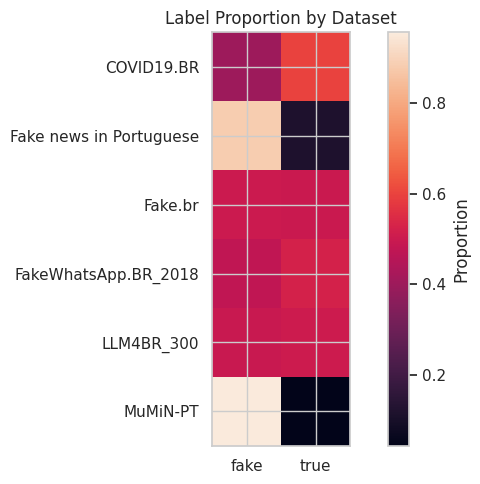

In [ ]:
# Calcular proporções
distribution = (
    df.groupby(['dataset_grouped', 'label'])
      .size()
      .unstack(fill_value=0)
)

proportions = distribution.div(distribution.sum(axis=1), axis=0)

# Converter para matriz
datasets = proportions.index
labels = proportions.columns
data = proportions.values

plt.figure(figsize=(8, 5))
plt.imshow(data)

plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(datasets)), datasets)

plt.colorbar(label="Proportion")

plt.title("Label Proportion by Dataset")
plt.tight_layout()
plt.show()

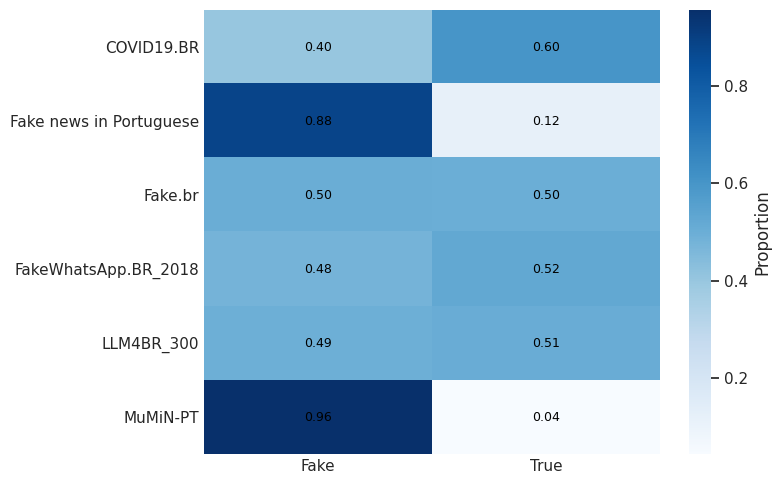

In [ ]:
plt.figure(figsize=(8, 5))

im = plt.imshow(data, cmap="Blues", aspect="auto")

plt.xticks(range(len(labels)), [label.capitalize() for label in labels])
plt.yticks(range(len(datasets)), datasets)

cbar = plt.colorbar(im)
cbar.set_label("Proportion")
cbar.outline.set_visible(False)

ax = plt.gca()
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(length=0)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        plt.text(j, i, f"{data[i, j]:.2f}",
                 ha="center", va="center",
                 color="black",
                 fontsize=9)

#plt.title("Label Distribution Across Source Datasets")
plt.tight_layout()

plt.savefig("label_distribution_heatmap.pdf", bbox_inches="tight")
plt.show()

In [ ]:
df["date_iso_parsed"] = pd.to_datetime(df["date_iso"], errors="coerce")


print("Datas válidas:", df["date_iso_parsed"].notna().sum())
print("Datas inválidas ou ausentes:", df["date_iso_parsed"].isna().sum())

print("\nIntervalo temporal do dataset:")
print("Data mínima:", df["date_iso_parsed"].min())
print("Data máxima:", df["date_iso_parsed"].max())

print("\nDistribuição por ano:")
display(
    df["date_iso_parsed"]
    .dt.year
    .value_counts()
    .sort_index()
)


Datas válidas: 26415
Datas inválidas ou ausentes: 24790

Intervalo temporal do dataset:
Data mínima: 2005-09-10 00:00:00
Data máxima: 2022-12-21 00:00:00

Distribuição por ano:


,count
date_iso_parsed,
2005.0,1
2010.0,2
2012.0,2
2013.0,2
2014.0,5
2015.0,41
2016.0,297
2017.0,461
2018.0,8150


In [ ]:
print("Quantidade de valores únicos em factcheck_rating:")
print(df["factcheck_rating"].nunique(dropna=True))

print("\nTop 20 valores mais frequentes (incluindo NaN):")
display(df["factcheck_rating"].value_counts(dropna=False).head(20))

print("\nExemplos de factcheck_rating longos (len > 80 caracteres):")
long_ratings = df["factcheck_rating"].dropna()
long_ratings = long_ratings[long_ratings.str.len() > 80]

display(long_ratings.head(10))


Quantidade de valores únicos em factcheck_rating:
304

Top 20 valores mais frequentes (incluindo NaN):


,count
factcheck_rating,
NaN,41898
falso,2589
Falso,2525
Errado,2049
Enganoso,473
Enganador,291
distorcido,169
Insustentável,129
Verdadeiro,86



Exemplos de factcheck_rating longos (len > 80 caracteres):


,factcheck_rating
9122,FALSO: O que o projeto de lei em tramitação na Câmara propõe é a definição de uma lista de pessoas prioritárias para uma possível campanha de imunização. A possibilidade de adoção de vacinação obr...
9131,ENGANOSO: O artigo que fala sobre o uso da hidroxicloroquina como tratamento precoce para a covid-19 foi publicado em agosto de 2020 e foi apenas revisado em janeiro deste ano. E não comprova a ef...
9188,"FALSO: Postagem usa suposto caso de mulher que caiu enquanto corria usando uma máscara para dizer que equipamento é prejudicial à saúde, mas autoridades negam que proteção cause danos graves. Além..."
9279,"FALSO: Ao contrário do que afirma vídeo publicado no YouTube, as vacinas mRNA são desenvolvidas para não interferir no DNA humano e não são capazes de provocar danos genéticos. Além disso, essas v..."
9285,"FALSO: As vacinas de mRNA são desenvolvidas para não interferir no DNA humano e não há qualquer evidência de que sejam capazes de causar danos genéticos. Além disso, o site que havia publicado o a..."
9287,"FALSO: As vacinas de mRNA são desenvolvidas para não interferir no DNA humano e não há qualquer evidência de que sejam capazes de causar danos genéticos. Além disso, o site que havia publicado o a..."
9435,"FALSO: Todos os imunizantes passaram por fases de testes, cujos dados são públicos, e, antes de serem aplicados, suas segurança e eficácia são analisadas pela autoridade sanitária de cada país."
9439,"FALSO: Todos os imunizantes passaram por fases de testes, cujos dados são públicos, e, antes de serem aplicados, suas segurança e eficácia são analisadas pela autoridade sanitária de cada país."
9442,"FALSO: Todos os imunizantes passaram por fases de testes, cujos dados são públicos, e, antes de serem aplicados, suas segurança e eficácia são analisadas pela autoridade sanitária de cada país."
9443,"ENGANOSO: Com números equivocados e afirmações desconectadas dos fatos, ex-ministro do governo Bolsonaro insinua que pessoas abaixo de 35 anos não deveriam ser vacinadas contra a covid-19"


In [ ]:
def normalize_factcheck_rating(rating):
    if pd.isna(rating):
        return "not_available"

    r = rating.lower()

    if "falso" in r or "errado" in r:
        return "false"
    elif "enganoso" in r:
        return "misleading"
    elif "verdadeiro" in r or "true" in r:
        return "true"
    elif "sem evidência" in r or "sem registro" in r:
        return "unverified"
    else:
        return "other"

df["factcheck_rating_normalized"] = df["factcheck_rating"].apply(normalize_factcheck_rating)

print("Distribuição do factcheck_rating_normalized:")
display(df["factcheck_rating_normalized"].value_counts())


Distribuição do factcheck_rating_normalized:


,count
factcheck_rating_normalized,
not_available,41898
false,7337
other,1136
misleading,667
true,136
unverified,31


In [ ]:
print("Contagem global dos flags de limpeza:\n")

flags = ["is_duplicated", "is_null", "too_short"]

for flag in flags:
    print(f"{flag}:")
    display(df[flag].value_counts())
    print("-" * 40)

# Contagem por dataset
print("\nContagem de flags de limpeza por dataset_name:\n")

for flag in flags:
    print(f"\nFlag: {flag}")
    display(
        df.groupby("dataset_name")[flag]
        .sum()
        .sort_values(ascending=False)
    )


Contagem global dos flags de limpeza:

is_duplicated:


,count
is_duplicated,
0,51205


----------------------------------------
is_null:


,count
is_null,
0,51205


----------------------------------------
too_short:


...

,is_duplicated
dataset_name,
COVID19.BR,0
COVID19.BR_raw,0
Fake.br,0
Fake.br_raw,0
FakeWhatsApp.BR_2018,0
LLM4BR_300,0
MuMiN-PT,0
MuMiN-PT_raw,0
fakes,0



Flag: is_null


,is_null
dataset_name,
COVID19.BR,0
COVID19.BR_raw,0
Fake.br,0
Fake.br_raw,0
FakeWhatsApp.BR_2018,0
LLM4BR_300,0
MuMiN-PT,0
MuMiN-PT_raw,0
fakes,0



Flag: too_short


,too_short
dataset_name,
COVID19.BR,0
COVID19.BR_raw,0
Fake.br,0
Fake.br_raw,0
FakeWhatsApp.BR_2018,0
LLM4BR_300,0
MuMiN-PT,0
MuMiN-PT_raw,0
fakes,0


In [ ]:
def extract_domain(url):
    if pd.isna(url):
        return np.nan
    try:
        return urlparse(url).netloc.lower()
    except:
        return np.nan

df["domain_url_review"] = df["url_review"].apply(extract_domain)
df["domain_factcheck_url"] = df["factcheck_url"].apply(extract_domain)

print("Top 10 domínios de url_review:")
display(df["domain_url_review"].value_counts().head(10))

print("\nTop 10 domínios de factcheck_url:")
display(df["domain_factcheck_url"].value_counts().head(10))

df["same_domain"] = df["domain_url_review"] == df["domain_factcheck_url"]

print("\nComparação entre domínios (url_review vs factcheck_url):")
display(df["same_domain"].value_counts(dropna=False))


Top 10 domínios de url_review:


,count
domain_url_review,
lupa.uol.com.br,5956
poligrafo.sapo.pt,5029
www.boatos.org,2508
www.aosfatos.org,2504
politica.estadao.com.br,2217
observador.pt,1851
checamos.afp.com,1653
noticias.uol.com.br,1083
www.e-farsas.com,123



Top 10 domínios de factcheck_url:


,count
domain_factcheck_url,
www.aosfatos.org,2871
observador.pt,2446
noticias.uol.com.br,1532
checamos.afp.com,1231
lupa.uol.com.br,417
projetocomprova.com.br,413
www.estadao.com.br,275
oglobo.globo.com,59
aosfatos.org,22



Comparação entre domínios (url_review vs factcheck_url):


,count
same_domain,
False,46708
True,4497


In [ ]:
TEXT_COL = "text_clean"

df_text = df[df[TEXT_COL].notna()].copy()

print("Total de textos válidos:", len(df_text))

sample_size_per_label = 500

df_sample = (
    df_text
    .groupby("label", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), sample_size_per_label), random_state=42))
)

print("Tamanho da amostra para teste:", df_sample.shape)

print("\nDistribuição de labels na amostra:")
display(df_sample["label"].value_counts())


Total de textos válidos: 51205
Tamanho da amostra para teste: (1000, 22)

Distribuição de labels na amostra:


/tmp/ipython-input-176034320.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), sample_size_per_label), random_state=42))


,count
label,
fake,500
true,500


In [ ]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9
)

X = vectorizer.fit_transform(df_sample[TEXT_COL])

similarity_matrix = cosine_similarity(X)

SIM_THRESHOLD = 0.85

near_duplicates = []

n = similarity_matrix.shape[0]

for i in range(n):
    for j in range(i + 1, n):
        sim = similarity_matrix[i, j]
        if sim >= SIM_THRESHOLD:
            near_duplicates.append({
                "idx_1": df_sample.index[i],
                "idx_2": df_sample.index[j],
                "similarity": sim,
                "label_1": df_sample.iloc[i]["label"],
                "label_2": df_sample.iloc[j]["label"]
            })

df_near_dups = pd.DataFrame(near_duplicates)

print("Quantidade de pares quase-duplicados encontrados:", len(df_near_dups))

if not df_near_dups.empty:
    print("\nDistribuição de conflitos de label:")
    display(
        df_near_dups
        .assign(label_conflict=lambda x: x["label_1"] != x["label_2"])
        ["label_conflict"]
        .value_counts()
    )

    print("\nExemplos de quase-duplicatas:")
    display(df_near_dups.head(10))
else:
    print("Nenhum par encontrado com o threshold atual.")


Quantidade de pares quase-duplicados encontrados: 15

Distribuição de conflitos de label:


,count
label_conflict,
False,15



Exemplos de quase-duplicatas:


,idx_1,idx_2,similarity,label_1,label_2
0,16498,15562,0.997943,fake,fake
1,13020,11442,0.987915,fake,fake
2,25759,50472,0.959593,fake,fake
3,3450,18718,1.000000,fake,fake
4,15987,15805,0.986680,fake,fake
5,2917,18183,1.000000,true,true
6,46689,46729,0.884714,true,true
7,14970,15879,0.948730,true,true
8,8437,23719,1.000000,true,true
9,17811,2553,1.000000,true,true


In [ ]:
SIM_THRESHOLD = 0.90

results_by_dataset = []

for dataset_name, group in df.groupby("dataset_name"):
    texts = group[TEXT_COL].dropna().tolist()

    if len(texts) < 50:
        continue

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9
    )

    X = vectorizer.fit_transform(texts)
    sim_matrix = cosine_similarity(X)

    count_pairs = 0
    conflict_pairs = 0

    labels = group["label"].tolist()

    n = sim_matrix.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            if sim_matrix[i, j] >= SIM_THRESHOLD:
                count_pairs += 1
                if labels[i] != labels[j]:
                    conflict_pairs += 1

    results_by_dataset.append({
        "dataset_name": dataset_name,
        "num_texts": len(texts),
        "near_duplicate_pairs": count_pairs,
        "label_conflict_pairs": conflict_pairs
    })

df_near_dup_summary = pd.DataFrame(results_by_dataset)

display(df_near_dup_summary.sort_values("near_duplicate_pairs", ascending=False))


,dataset_name,num_texts,near_duplicate_pairs,label_conflict_pairs
4,FakeWhatsApp.BR_2018,6383,6230,178
1,COVID19.BR_raw,2325,509,18
8,fakes,20364,507,0
0,COVID19.BR,1952,424,8
6,MuMiN-PT,1403,37,0
7,MuMiN-PT_raw,1403,37,0
3,Fake.br_raw,7199,13,0
2,Fake.br,7160,9,0
9,true,2717,7,0
5,LLM4BR_300,299,2,0


In [ ]:
audit_columns = [
    "rid_1",
    "rid_2",
    "similarity",
    "label_1",
    "label_2",
    "dataset_name",
    "decision",          # manter / corrigir
    "final_label",       # se corrigido
    "notes"              # justificativa humana
]

audit_table = pd.DataFrame(columns=audit_columns)

print("Estrutura da tabela de auditoria criada.")
audit_table


Estrutura da tabela de auditoria criada.


,rid_1,rid_2,similarity,label_1,label_2,dataset_name,decision,final_label,notes


In [ ]:
SIM_THRESHOLD = 0.90

conflict_records = []

for dataset_name, group in df.groupby("dataset_name"):
    texts = group[TEXT_COL].dropna().tolist()
    labels = group["label"].tolist()
    rids = group["rid"].tolist()

    if len(texts) < 50:
        continue

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9
    )

    X = vectorizer.fit_transform(texts)
    sim_matrix = cosine_similarity(X)

    n = sim_matrix.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            sim = sim_matrix[i, j]
            if sim >= SIM_THRESHOLD and labels[i] != labels[j]:
                conflict_records.append({
                    "rid_1": rids[i],
                    "rid_2": rids[j],
                    "similarity": sim,
                    "label_1": labels[i],
                    "label_2": labels[j],
                    "dataset_name": dataset_name
                })

df_conflicts = pd.DataFrame(conflict_records)

print("Total de pares com conflito de label:", len(df_conflicts))

print("\nConflitos por dataset:")
display(df_conflicts["dataset_name"].value_counts())

print("\nExemplos de conflitos encontrados:")
display(df_conflicts.head(10))


Total de pares com conflito de label: 204

Conflitos por dataset:


,count
dataset_name,
FakeWhatsApp.BR_2018,178
COVID19.BR_raw,18
COVID19.BR,8



Exemplos de conflitos encontrados:


,rid_1,rid_2,similarity,label_1,label_2,dataset_name
0,71,914,0.931698,fake,true,COVID19.BR
1,246,1324,0.927381,true,fake,COVID19.BR
2,311,1095,0.946553,fake,true,COVID19.BR
3,311,1927,0.985758,fake,true,COVID19.BR
4,329,1834,0.986633,true,fake,COVID19.BR
5,362,919,0.956915,true,fake,COVID19.BR
6,549,982,0.933659,fake,true,COVID19.BR
7,1119,1834,0.994710,true,fake,COVID19.BR
8,44832,45780,0.924303,fake,true,COVID19.BR_raw
9,44848,45484,0.977717,fake,true,COVID19.BR_raw


In [ ]:
df_conflicts_full = (
    df_conflicts
    .merge(df[["rid", "factcheck_rating_normalized", "factcheck_claimant"]],
           left_on="rid_1", right_on="rid", how="left")
    .rename(columns={
        "factcheck_rating_normalized": "rating_1",
        "factcheck_claimant": "claimant_1"
    })
    .drop(columns=["rid"])
    .merge(df[["rid", "factcheck_rating_normalized", "factcheck_claimant"]],
           left_on="rid_2", right_on="rid", how="left")
    .rename(columns={
        "factcheck_rating_normalized": "rating_2",
        "factcheck_claimant": "claimant_2"
    })
    .drop(columns=["rid"])
)

print("Distribuição de ratings no lado 1 dos conflitos:")
display(df_conflicts_full["rating_1"].value_counts(dropna=False))

print("\nDistribuição de ratings no lado 2 dos conflitos:")
display(df_conflicts_full["rating_2"].value_counts(dropna=False))

print("\nTop 10 claimants envolvidos em conflitos (lado 1):")
display(df_conflicts_full["claimant_1"].value_counts().head(10))

print("\nTop 10 claimants envolvidos em conflitos (lado 2):")
display(df_conflicts_full["claimant_2"].value_counts().head(10))


Distribuição de ratings no lado 1 dos conflitos:


,count
rating_1,
not_available,204



Distribuição de ratings no lado 2 dos conflitos:


,count
rating_2,
not_available,204



Top 10 claimants envolvidos em conflitos (lado 1):


,count
claimant_1,



Top 10 claimants envolvidos em conflitos (lado 2):


,count
claimant_2,


In [ ]:
audit_table = df_conflicts.copy()

audit_table["decision"] = "keep"
audit_table["final_label"] = audit_table["label_1"]
audit_table["notes"] = (
    "Conflito de label detectado entre quase-duplicatas. "
    "Nenhum fact-check disponível (rating e claimant ausentes). "
    "Decisão conservadora: manter rótulos originais."
)

print("Resumo das decisões da auditoria:")
display(audit_table["decision"].value_counts())

print("\nExemplo de registros auditados:")
display(audit_table.head(10))


Resumo das decisões da auditoria:


,count
decision,
keep,204



Exemplo de registros auditados:


,rid_1,rid_2,similarity,label_1,label_2,dataset_name,decision,final_label,notes
0,71,914,0.931698,fake,true,COVID19.BR,keep,fake,Conflito de label detectado entre quase-duplicatas. Nenhum fact-check disponível (rating e claimant ausentes). Decisão conservadora: manter rótulos originais.
1,246,1324,0.927381,true,fake,COVID19.BR,keep,true,Conflito de label detectado entre quase-duplicatas. Nenhum fact-check disponível (rating e claimant ausentes). Decisão conservadora: manter rótulos originais.
2,311,1095,0.946553,fake,true,COVID19.BR,keep,fake,Conflito de label detectado entre quase-duplicatas. Nenhum fact-check disponível (rating e claimant ausentes). Decisão conservadora: manter rótulos originais.
3,311,1927,0.985758,fake,true,COVID19.BR,keep,fake,Conflito de label detectado entre quase-duplicatas. Nenhum fact-check disponível (rating e claimant ausentes). Decisão conservadora: manter rótulos originais.
4,329,1834,0.986633,true,fake,COVID19.BR,keep,true,Conflito de label detectado entre quase-duplicatas. Nenhum fact-check disponível (rating e claimant ausentes). Decisão conservadora: manter rótulos originais.
5,362,919,0.956915,true,fake,COVID19.BR,keep,true,Conflito de label detectado entre quase-duplicatas. Nenhum fact-check disponível (rating e claimant ausentes). Decisão conservadora: manter rótulos originais.
6,549,982,0.933659,fake,true,COVID19.BR,keep,fake,Conflito de label detectado entre quase-duplicatas. Nenhum fact-check disponível (rating e claimant ausentes). Decisão conservadora: manter rótulos originais.
7,1119,1834,0.994710,true,fake,COVID19.BR,keep,true,Conflito de label detectado entre quase-duplicatas. Nenhum fact-check disponível (rating e claimant ausentes). Decisão conservadora: manter rótulos originais.
8,44832,45780,0.924303,fake,true,COVID19.BR_raw,keep,fake,Conflito de label detectado entre quase-duplicatas. Nenhum fact-check disponível (rating e claimant ausentes). Decisão conservadora: manter rótulos originais.
9,44848,45484,0.977717,fake,true,COVID19.BR_raw,keep,fake,Conflito de label detectado entre quase-duplicatas. Nenhum fact-check disponível (rating e claimant ausentes). Decisão conservadora: manter rótulos originais.


In [ ]:
df["in_label_conflict"] = df["rid"].isin(
    audit_table["rid_1"].tolist() + audit_table["rid_2"].tolist()
)

print("Quantidade de registros envolvidos em conflitos:")
print(df["in_label_conflict"].value_counts())

OUTPUT_PATH = "FakenewsBR_factchecked_audited.csv"
df.to_csv(OUTPUT_PATH, index=False)

print(f"\nDataset auditado salvo com sucesso em: {OUTPUT_PATH}")


Quantidade de registros envolvidos em conflitos:
in_label_conflict
False    50988
True       217
Name: count, dtype: int64

Dataset auditado salvo com sucesso em: FakenewsBR_factchecked_audited.csv


In [ ]:
import pandas as pd

df = pd.read_csv("FakenewsBR_factchecked_audited.csv")
print(f"Número de linhas no arquivo: {len(df)}")


Número de linhas no arquivo: 51205


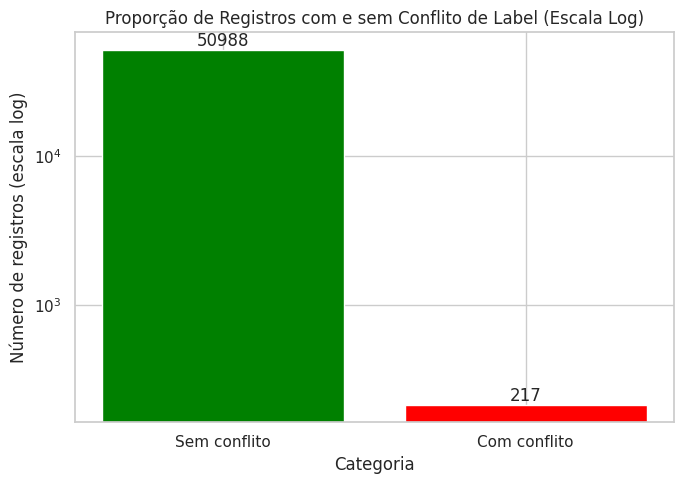

In [ ]:
conflict_counts = df["in_label_conflict"].value_counts()

labels = ["Sem conflito", "Com conflito"]
values = [
    conflict_counts.get(False, 0),
    conflict_counts.get(True, 0)
]

colors = ["green", "red"]

plt.figure(figsize=(7, 5))
plt.bar(labels, values, color=colors)
plt.yscale("log")

plt.title("Proporção de Registros com e sem Conflito de Label (Escala Log)")
plt.ylabel("Número de registros (escala log)")
plt.xlabel("Categoria")

for i, v in enumerate(values):
    plt.text(i, v, f"{v}", ha="center", va="bottom")

plt.tight_layout()
plt.show()


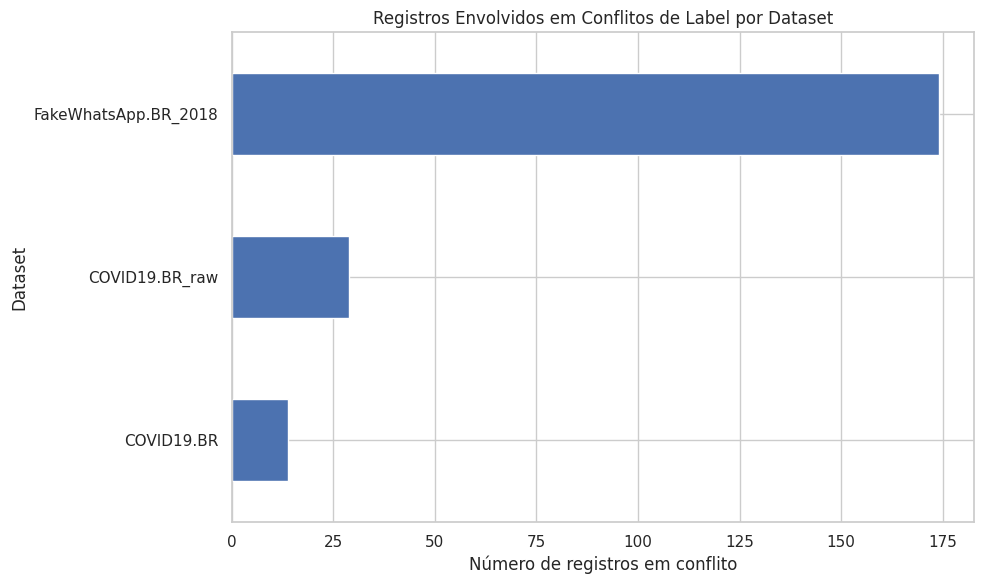

In [ ]:
conflicts_by_dataset = (
    df[df["in_label_conflict"]]
    .groupby("dataset_name")
    .size()
    .sort_values()
)

plt.figure(figsize=(10, 6))
conflicts_by_dataset.plot(kind="barh")

plt.title("Registros Envolvidos em Conflitos de Label por Dataset")
plt.xlabel("Número de registros em conflito")
plt.ylabel("Dataset")

plt.tight_layout()
plt.show()


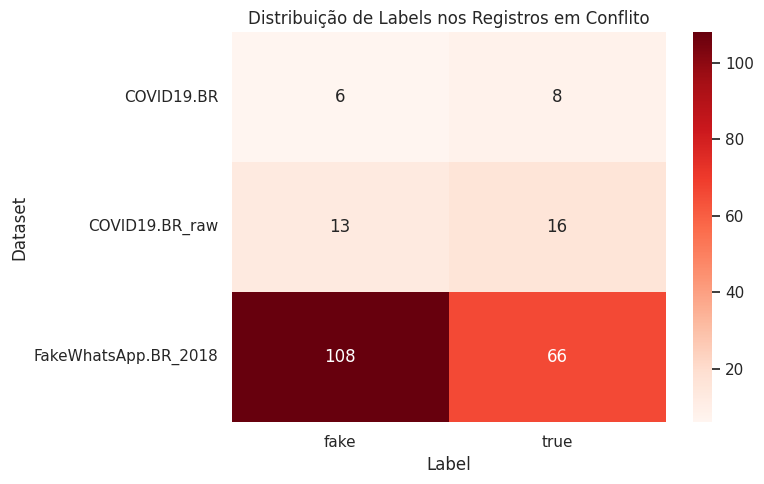

In [ ]:
df_conflict_only = df[df["in_label_conflict"]]

heatmap_data = pd.crosstab(
    df_conflict_only["dataset_name"],
    df_conflict_only["label"]
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.title("Distribuição de Labels nos Registros em Conflito")
plt.xlabel("Label")
plt.ylabel("Dataset")
plt.tight_layout()
plt.show()


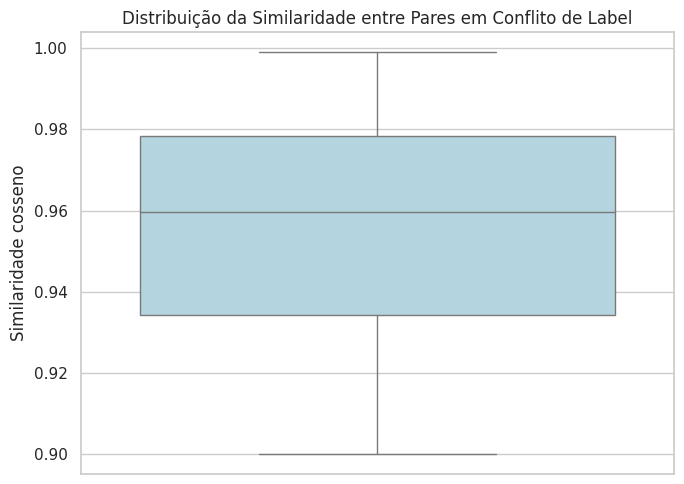

In [ ]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    y=df_conflicts["similarity"],
    color="lightblue"
)

plt.title("Distribuição da Similaridade entre Pares em Conflito de Label")
plt.ylabel("Similaridade cosseno")
plt.tight_layout()
plt.show()


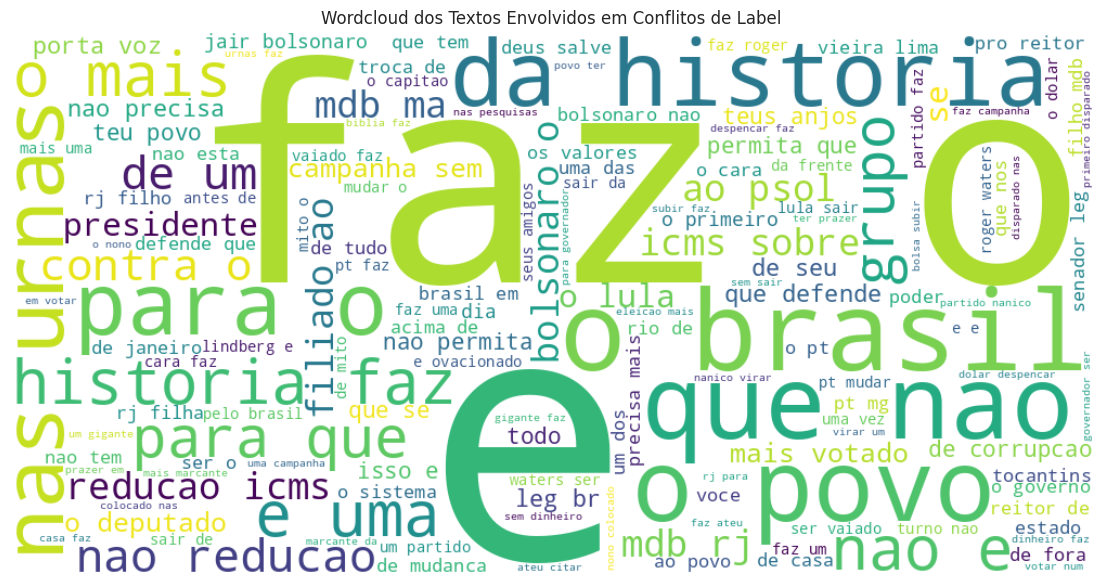

In [ ]:
from wordcloud import WordCloud

conflict_texts = df[df["in_label_conflict"]]["text_clean"].dropna()

text_blob = " ".join(conflict_texts.tolist())

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="viridis",
    max_words=150
).generate(text_blob)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Wordcloud dos Textos Envolvidos em Conflitos de Label")
plt.tight_layout()
plt.show()


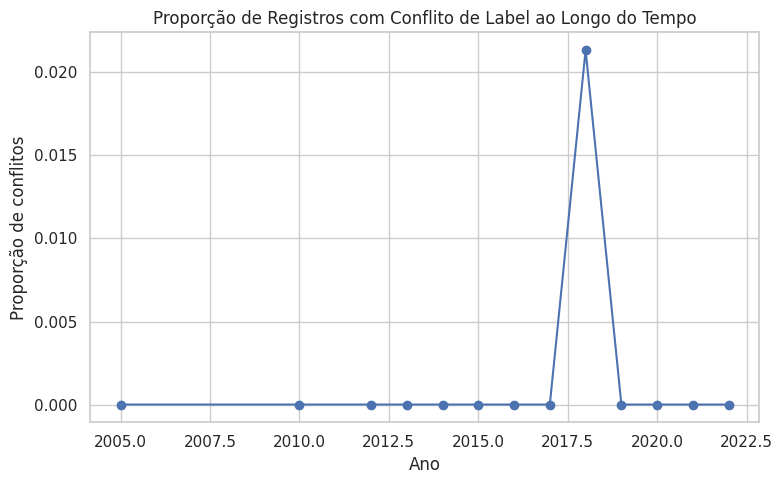

In [ ]:
df_time = df[df["date_iso_parsed"].notna()].copy()

df_time["year"] = df_time["date_iso_parsed"].dt.year

conflict_ratio_by_year = (
    df_time
    .groupby("year")["in_label_conflict"]
    .mean()
)

plt.figure(figsize=(8, 5))
plt.plot(
    conflict_ratio_by_year.index,
    conflict_ratio_by_year.values,
    marker="o"
)

plt.title("Proporção de Registros com Conflito de Label ao Longo do Tempo")
plt.xlabel("Ano")
plt.ylabel("Proporção de conflitos")
plt.grid(True)
plt.tight_layout()
plt.show()
